In [3]:
from housing.data import setup_logging, dataset_loader
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import logging 
from pathlib import Path
from sklearn.preprocessing import PowerTransformer , FunctionTransformer , StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.metrics.pairwise import rbf_kernel
from sklearn.pipeline import make_pipeline , Pipeline
from sklearn.base import BaseEstimator , TransformerMixin
from sklearn.utils.validation import check_array , check_is_fitted
from sklearn.model_selection import StratifiedShuffleSplit 
from sklearn.preprocessing import OneHotEncoder
from sklearn.cluster import KMeans
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet, SGDRegressor, HuberRegressor ,RANSACRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.model_selection import cross_val_score , RandomizedSearchCV
from sklearn.metrics import root_mean_squared_error
import joblib


In [4]:
from sklearn import set_config
set_config(display='text')

In [5]:
setup_logging()
housing = dataset_loader()
housing.head()

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY


In [6]:
sns.set_style('whitegrid')
def plot_histogram(
    data: pd.DataFrame,
    title: str,
    color_face : str = 'deepskyblue',
    color_edge : str = 'blue',
    figsize : tuple = (12,9),
    bins : int = 50
) -> None:    

    data.hist(bins=bins, figsize=figsize,
              color=color_face,
              edgecolor=color_edge)
    
    plt.suptitle(title, fontsize=16)
    plt.tight_layout()
    plt.show()

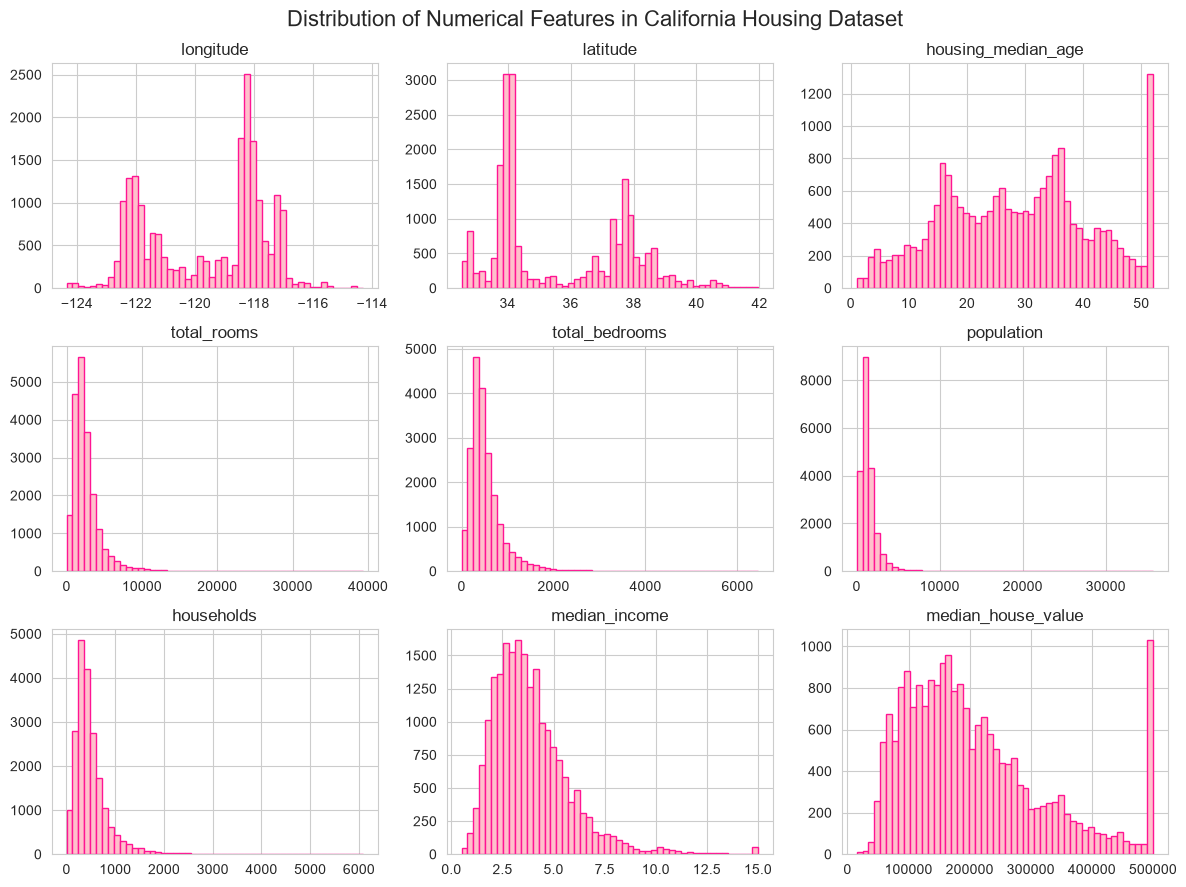

In [7]:
plot_histogram(
    data=housing.select_dtypes(np.number),
    title='Distribution of Numerical Features in California Housing Dataset',
    color_face='pink',
    color_edge='deeppink'
)

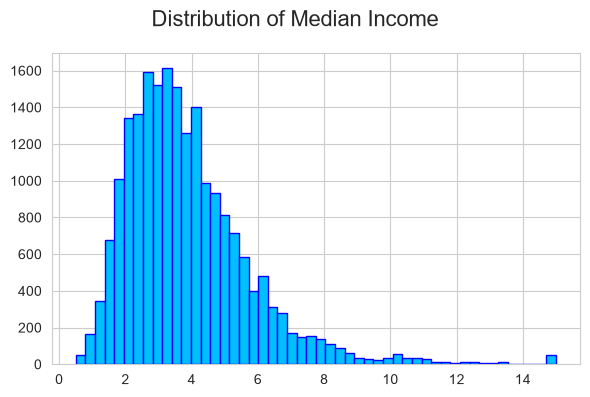

In [8]:
plot_histogram(
    data=housing['median_income'],
    title='Distribution of Median Income',
    figsize=(6,4)
)

In [9]:
income_bins = [0, 1.5, 3, 4.5, 6, np.inf]
income_labels = [1, 2, 3, 4, 5]

#TODO: This column should be removed after splitting

housing['median_income_category'] = pd.cut(
    housing['median_income'],
    bins=income_bins,
    labels=income_labels,
)

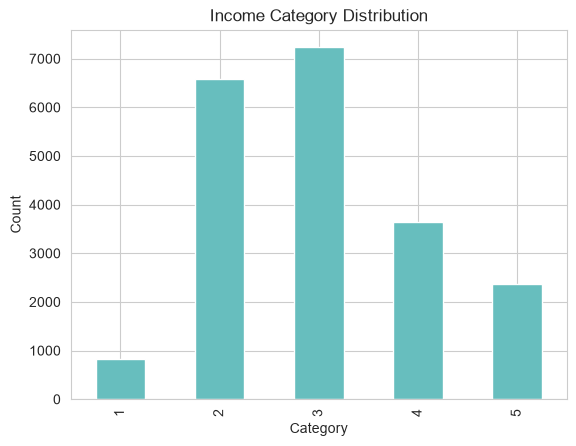

In [10]:
housing['median_income_category'].value_counts().sort_index().plot(kind='bar' , color="#67bebe")
plt.title('Income Category Distribution')
plt.xlabel('Category')
plt.ylabel('Count')
plt.show()

In [11]:
splitter = StratifiedShuffleSplit(n_splits=10,
                                 test_size=0.2,
                                 random_state=42)

In [12]:
strat_splits = []
for train_index , test_index in splitter.split(housing , housing['median_income_category']):
    strat_train_set_n = housing.iloc[train_index]
    strat_test_set_n = housing.iloc[test_index]
    strat_splits.append([strat_train_set_n ,strat_test_set_n])

In [13]:
strat_train_set, strat_test_set = strat_splits[0]

strat_train_set = strat_train_set.copy()
strat_test_set = strat_test_set.copy()

for subset in (strat_train_set, strat_test_set):
    subset.drop('median_income_category', axis=1, inplace=True)

In [14]:
x_train = strat_train_set.drop(['median_house_value'] , axis=1)
x_test = strat_test_set.drop(['median_house_value'] , axis=1)

In [15]:
y_train = strat_train_set['median_house_value']
y_test = strat_test_set['median_house_value']

In [16]:
strat_train_set.corr(numeric_only=True)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
longitude,1.000000,-0.924213,-0.102937,0.044558,0.068210,0.104236,0.054261,-0.016542,-0.050859
latitude,-0.924213,1.000000,0.005692,-0.036753,-0.066391,-0.115677,-0.071604,-0.078137,-0.139584
housing_median_age,-0.102937,0.005692,1.000000,-0.361710,-0.317978,-0.301906,-0.300075,-0.127043,0.102175
total_rooms,0.044558,-0.036753,-0.361710,1.000000,0.930076,0.863967,0.916143,0.197720,0.137455
total_bedrooms,0.068210,-0.066391,-0.317978,0.930076,1.000000,0.886200,0.978822,-0.006038,0.054635
population,0.104236,-0.115677,-0.301906,0.863967,0.886200,1.000000,0.916237,0.004282,-0.020153
households,0.054261,-0.071604,-0.300075,0.916143,0.978822,0.916237,1.000000,0.013637,0.071426
median_income,-0.016542,-0.078137,-0.127043,0.197720,-0.006038,0.004282,0.013637,1.000000,0.688380
median_house_value,-0.050859,-0.139584,0.102175,0.137455,0.054635,-0.020153,0.071426,0.688380,1.000000


Checked correlation between features  — values close to
1 mean strong positive relationship (one goes up, other goes up too),
close to -1 means inverse relationship, and close to 0 means no clear
linear relationship.



Therefore, I checked correlation across the whole dataset and noticed that
longitude and latitude have a strong relationship with each other
(makes sense, they're geographic coordinates). So I plotted them
directly to see the spatial pattern more clearly.

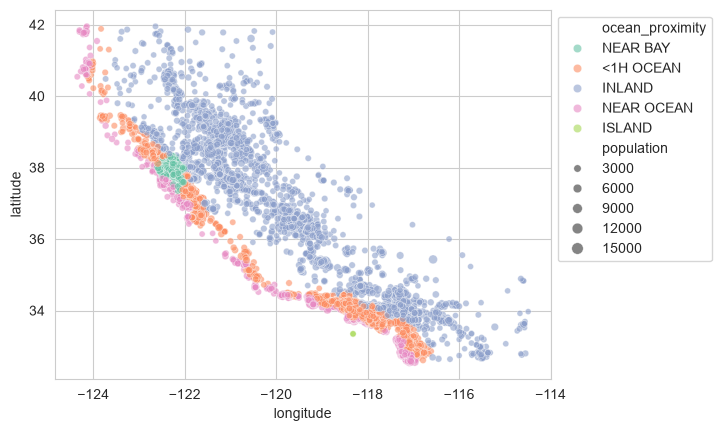

In [17]:
sns.set_style('whitegrid')
ax = sns.scatterplot(data=x_train,
                     x='longitude',
                     y='latitude',
                     alpha=0.6,
                     size='population',
                     hue='ocean_proximity',
                     palette='Set2',
                     legend=True)

sns.move_legend(ax ,'upper left', bbox_to_anchor=(1,1))
plt.show()

In [18]:
strat_train_set.corr(numeric_only=True)[['median_house_value']]

,median_house_value
longitude,-0.050859
latitude,-0.139584
housing_median_age,0.102175
total_rooms,0.137455
total_bedrooms,0.054635
population,-0.020153
households,0.071426
median_income,0.688380
median_house_value,1.000000


Also, I checked correlation between features and target .
From this, `median_income` had the strongest correlation with
`median_house_value`. So I plotted them against each other to see this
relationship more clearly, and colored points by `ocean_proximity` —
you can clearly see homes closer to the ocean tend to have higher
prices, and homes farther away are cheaper.

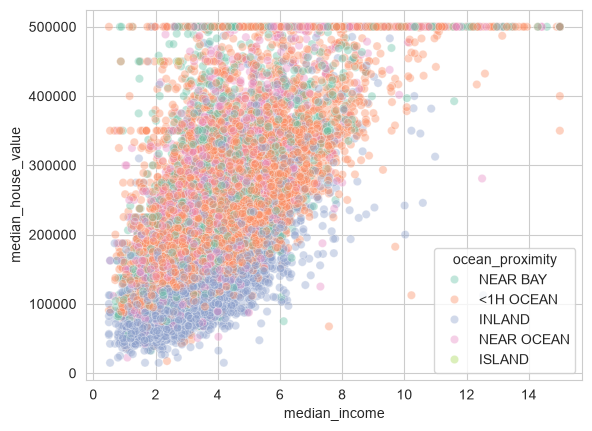

In [19]:
sns.scatterplot(
    data=strat_train_set,
    x='median_income',
    y='median_house_value',
    hue='ocean_proximity',
    palette='Set2',
    alpha=0.4
)
plt.show()

In [20]:
skewness = x_train.select_dtypes(np.number).skew().sort_values(ascending=False)
skewness

total_rooms           4.163762
total_bedrooms        3.444447
households            3.357607
population            3.283510
median_income         1.617601
latitude              0.448789
housing_median_age    0.061423
longitude            -0.287729
dtype: float64

<span style="color:#e6ffcc">Identifying features that truly exhibit skewness.<span>

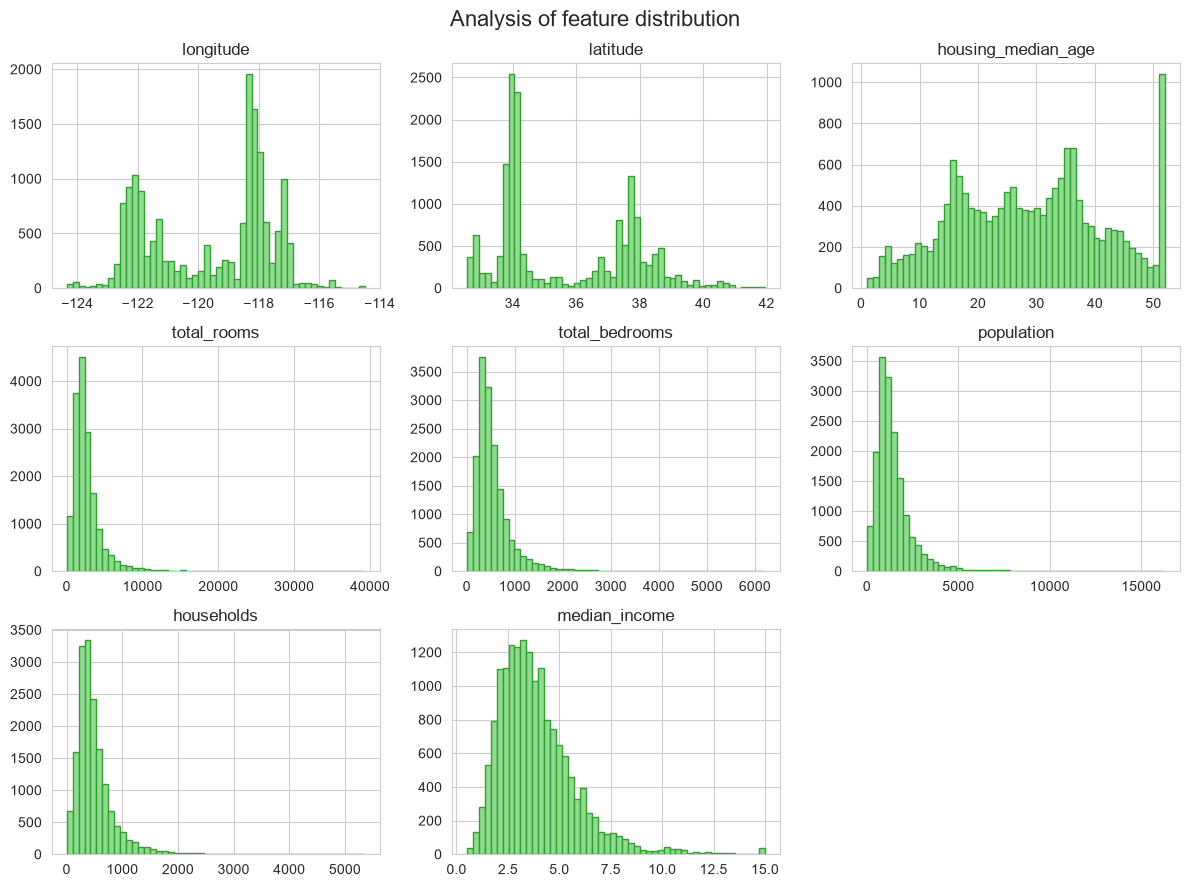

In [21]:
plot_histogram(
    x_train.select_dtypes(np.number),
    'Analysis of feature distribution',
    "#91db91",
    "#2f9f2f"
)

> As you can see, out of the eight charts, only five exhibit signs of skewness, while the others are `multimodal`.

In [56]:
skewness_correction_pipeline = Pipeline([
    ('impute_skewed' ,SimpleImputer(strategy='median')),
    ('powertransformer' ,PowerTransformer(standardize=True))])


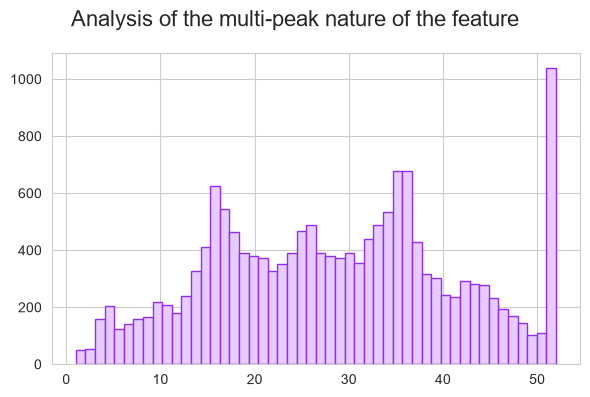

In [23]:
plot_histogram(
    x_train['housing_median_age'],
    "Analysis of the multi-peak nature of the feature",
    color_face='#e6ccff',
    color_edge="#932bfb",
    figsize=(6,4)
)


As you can see from the histogram, `housing_median_age` is a multimodal
feature — the data is concentrated around a few different age ranges,
which can be tricky for models to handle. If we use transformers like
PowerTransformer or QuantileTransformer, they'd change the shape of the
distribution and we might lose some of that information.

So instead, we use RBF kernel similarity: pick a reference point (a
"peak"), and measure how similar every other value is to that point.

We wrote our own transformer around `rbf_kernel` instead of using it
directly, so we can try multiple gamma values and multiple reference
points and tune them with RandomizedSearchCV. This also gives us more
control and flexibility over how the similarity is computed.

<span style="color:lightblue">The following example shows why the gamma value is important.<span>

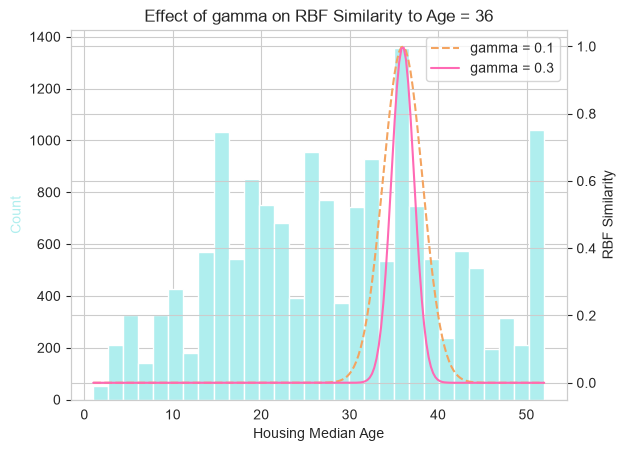

In [24]:
fig, ax = plt.subplots()

ax.hist(x_train['housing_median_age'], bins=30, color='PaleTurquoise')
ax.set_xlabel('Housing Median Age')
ax.set_ylabel('Count', color='PaleTurquoise')

n_points = 200
housing_ages = np.linspace(
    x_train['housing_median_age'].min(),
    x_train['housing_median_age'].max(),
    n_points
).reshape(-1, 1)

rbf1 = rbf_kernel(housing_ages, [[36]], gamma=0.1)
rbf2 = rbf_kernel(housing_ages, [[36]], gamma=0.3)

ax2 = ax.twinx()  
ax2.plot(housing_ages, rbf1, color="SandyBrown", ls='--', label='gamma = 0.1')
ax2.plot(housing_ages, rbf2, color="HotPink", label='gamma = 0.3')
ax2.set_ylabel('RBF Similarity')

plt.title('Effect of gamma on RBF Similarity to Age = 36')
plt.legend()
plt.show()

In [25]:
logger = logging.getLogger(__name__)

class RBFSimilarity(BaseEstimator, TransformerMixin):
    def __init__(self, reference_values, gamma=0.1):
        self.reference_values = reference_values
        self.gamma = gamma

    def fit(self, x, y=None):
        x = check_array(x)
        self.n_features_in_ = x.shape[1]
        logger.info(
            'Fitted RBFSimilarity with %d reference value(s), gamma=%s, n_features_in_=%d',
            len(self.reference_values), self.gamma, self.n_features_in_,
        )
        return self

    def transform(self, x):
        check_is_fitted(self)
        x = check_array(x)
        if x.shape[1] != self.n_features_in_:
            logger.error(
                'Shape mismatch: expected %d features, got %d',
                self.n_features_in_, x.shape[1],
            )
            raise ValueError(
                f"x has {x.shape[1]} features, but RBFSimilarity was fitted with {self.n_features_in_} features."
            )
        references = np.array(self.reference_values).reshape(-1, 1)
        result = rbf_kernel(x, references, gamma=self.gamma)  #similarity = exp(-gamma * (x - reference)²)
        logger.debug('Transformed %d samples into %d similarity feature(s)',
                     x.shape[0],
                     result.shape[1])
        
        return result


    def get_feature_names_out(self, input_features=None):
        return [f"age_similarity_{value}" for value in self.reference_values]

In [55]:
age_similarity_pipeline = Pipeline([
    ('impute_age', SimpleImputer(strategy='median')),
    ('rbf', RBFSimilarity(reference_values=[35], gamma=0.1)),
])

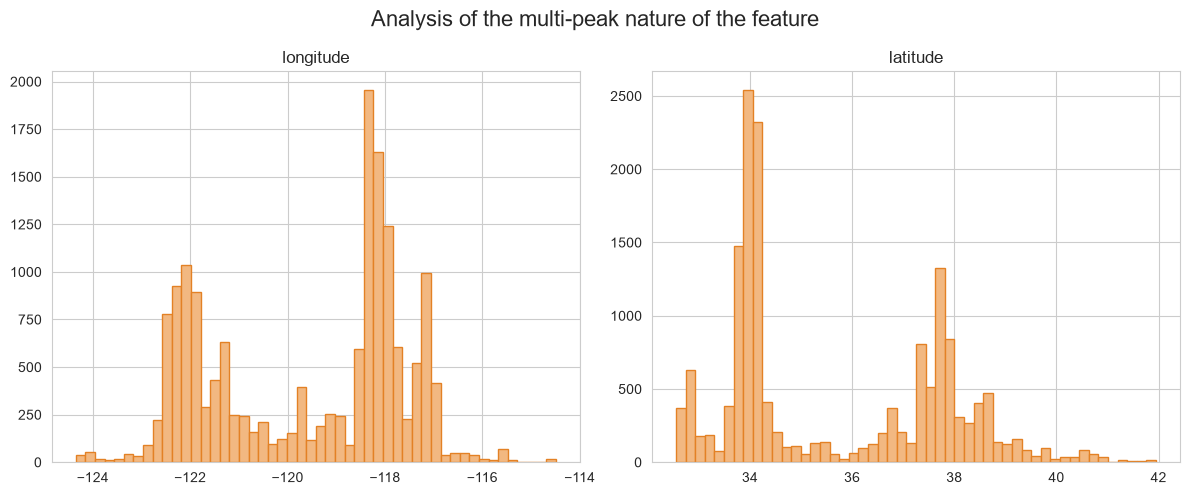

In [27]:
plot_histogram(
    x_train[['longitude', 'latitude']],
    "Analysis of the multi-peak nature of the feature",
    color_face="#f2b881",
    color_edge="#e38125",
    figsize=(12,5)
)


Similar idea to the age similarity feature, but for `longitude`/`latitude`.
The difference here is instead of picking a reference point manually,
we use KMeans to find cluster centers from the data itself, then measure each house's similarity to those centers
with RBF kernel. Makes more sense than picking points by hand since we don't really know where the "important" locations are ahead of time.

In [28]:
class GeoClusterSimilarity(BaseEstimator, TransformerMixin):
   
    def __init__(self, n_clusters=10, gamma=1.0, random_state=None):
        self.n_clusters = n_clusters
        self.gamma = gamma
        self.random_state = random_state

    def fit(self, x, y=None, sample_weight=None):
        x = check_array(x)
        self.kmeans_ = KMeans(
            self.n_clusters, random_state=self.random_state, n_init=10
        )
        self.kmeans_.fit(x, sample_weight=sample_weight)
        self.n_features_in_ = x.shape[1]
        logger.info(
            'Fitted GeoClusterSimilarity with %d clusters, gamma=%s',
            self.n_clusters, self.gamma,
        )
        return self

    def transform(self, x):
        check_is_fitted(self)
        x = check_array(x)
        if x.shape[1] != self.n_features_in_:
            logger.error(
                'Shape mismatch: expected %d features, got %d',
                self.n_features_in_, x.shape[1],
            )
            raise ValueError(
                f'x has {x.shape[1]} features, but GeoClusterSimilarity was fitted with {self.n_features_in_} features.'
            )
        return rbf_kernel(x, self.kmeans_.cluster_centers_, gamma=self.gamma)

    def get_feature_names_out(self, input_features=None):
        return [f"geo_cluster_{i}_similarity" for i in range(self.n_clusters)]

In [57]:
geo_pipeline = Pipeline([
    ('impute_geo', SimpleImputer(strategy='median')),
    ('geo_cluster', GeoClusterSimilarity(n_clusters=10, gamma=1.0, random_state=42)),
])

In [30]:
def combine_feature(features):
    return features[: ,[0]] / features[: ,[1]]

def column_name(transformer , features_name_in):
    return [f'{features_name_in[0]}_per_{features_name_in[1]}']

In [58]:
make_new_column = Pipeline([
    ('impute_ratio', SimpleImputer(strategy='median')),
    ('combine', FunctionTransformer(combine_feature, feature_names_out=column_name)),
    ('scale', StandardScaler()),
])

In [59]:
cat_to_num_pipeline = Pipeline([
    ('impute_Cat',SimpleImputer(strategy='most_frequent')),
    ('ohe' ,OneHotEncoder(handle_unknown='ignore'))
])

In [33]:
skewed_features = ['total_rooms' , 'total_bedrooms', 'population', 'households','median_income' ]

In [34]:
preprocessing  = ColumnTransformer([
 ('skewed', skewness_correction_pipeline, skewed_features),
    ('age_similarity', age_similarity_pipeline, ['housing_median_age']),
    ('geo_similarity', geo_pipeline, ['longitude', 'latitude']),
    ('bedrooms_ratio', make_new_column, ['total_rooms', 'total_bedrooms',]),
    ('rooms_per_house', make_new_column, ['total_rooms', 'households']),
    ('people_per_house', make_new_column, ['population', 'households']),
    ('categorical', cat_to_num_pipeline, ['ocean_proximity']),
], remainder='passthrough')

preprocessing

ColumnTransformer(remainder='passthrough',
                  transformers=[('skewed',
                                 Pipeline(steps=[('impute_skewed',
                                                  SimpleImputer(strategy='median')),
                                                 ('powertransformer',
                                                  PowerTransformer())]),
                                 ['total_rooms', 'total_bedrooms', 'population',
                                  'households', 'median_income']),
                                ('age_similarity',
                                 Pipeline(steps=[('impute_age',
                                                  SimpleImputer(strategy='median')),
                                                 ('rbf',
                                                  RBFSimilar...
                                                 ('combine',
                                                  FunctionTransformer(feature_names_out=<

In [35]:
models = {
    'linear': LinearRegression(),
    'ridge': Ridge(random_state=42),
    'lasso': Lasso(random_state=42),
    'elasticnet': ElasticNet(random_state=42),
    'sgdregressor' : SGDRegressor(random_state=42),
    'huberregressor' : HuberRegressor(max_iter=1000),
    'ransacregressor' : RANSACRegressor(random_state=42),
    'decision_tree': DecisionTreeRegressor(random_state=42),
    'randomforest': RandomForestRegressor(random_state=42)
}

In [36]:
results = {}
for name, model in models.items():
    pipeline_model = Pipeline([('preprocessing', preprocessing), ('model', model)])
    scores = -cross_val_score(pipeline_model,
                               x_train,
                               y_train,
                               scoring='neg_root_mean_squared_error',
                               cv=5)
    results[name] = scores
    logger.info('%s: RMSE mean=%.2f, std=%.2f', name, scores.mean(), scores.std())
    print(f"{name}: RMSE mean={(scores).mean():.2f}, std={(scores).std():.2f}")

linear: RMSE mean=68160.85, std=431.30
ridge: RMSE mean=68168.01, std=419.40


c:\Users\Digital City\Ml_project\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.339009e+12, tolerance: 1.734e+10
  model = cd_fast.enet_coordinate_descent(
c:\Users\Digital City\Ml_project\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 5.430331e+12, tolerance: 1.767e+10
  model = cd_fast.enet_coordinate_descent(
c:\Users\Digital City\Ml_project\.venv\Lib\site-packages\sklearn\linear_model\_coordinate_descent.py:840: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing 

lasso: RMSE mean=68160.29, std=428.99
elasticnet: RMSE mean=82210.51, std=770.06
sgdregressor: RMSE mean=62282813.30, std=124177958.47
huberregressor: RMSE mean=69725.22, std=1028.02
ransacregressor: RMSE mean=1324253.94, std=2031922.44
decision_tree: RMSE mean=66756.81, std=1676.68
randomforest: RMSE mean=47478.31, std=513.96



The mean shows average model performance, and std shows how much
performance varies across folds. The error metric used here is RMSE
(lower is better), though it should always be judged relative to the
target's scale to know if it's actually good or bad. Since `cv=5`
creates 5 folds, the mean is the average RMSE across those 5 folds 
lower mean means better overall performance.

std measures how spread out the 5 fold scores are. If std is low, the
folds were fairly close to each other, meaning the model is more
stable. So overall, a good model is one with both low mean and low std.

`linear`, `ridge`, and `lasso` all performed similarly, with both mean
and std lower than most other models. `ridge` and `lasso` didn't show
much improvement over plain `linear` regression meaning
regularization didn't help much here, likely because the features
aren't heavily correlated or overly complex.

`SGDRegressor` and `RANSACRegressor` performed the worst, with very
high mean and std both diverged with default settings and would
need manual tuning of learning rate/iterations, which is outside the
scope of this project.

`decision_tree` had a lower mean RMSE than the linear models, but
noticeably less stability — meaning the tree structure can vary quite
a bit depending on which fold it's trained on.

`random_forest`, however, clearly outperformed everything else both
in mean RMSE  and stability. This makes sense: averaging predictions across many decision trees reduces the variance/instability that a single decision tree suffers from, while still capturing the non-linear patterns a single tree can learn. Based
on this, `random_forest` looks like the strongest candidate to move forward with and tune further.

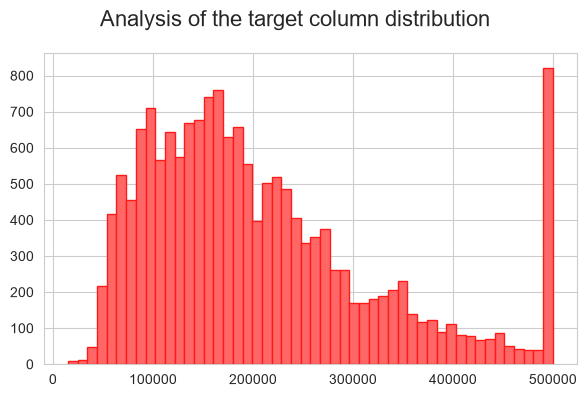

In [37]:
plot_histogram(
    y_train,
    'Analysis of the target column distribution',
    '#ff6666',
    '#ff1a1a',
    (6,4)
)

As shown in the chart, if we ignore the tail end of the distribution,
the target is `right-skewed` (and somewhat resembles a log-normal
distribution). This can hurt model performance, since the model isn't
learning from a well-behaved distribution. To fix this, we can apply a
log transform to the target column.

Instead of using a regular logarithm, we use `log(1+x)`, so that it's
also defined at zero. Since we're transforming the target variable,
we'll also need its inverse, `exp(x)-1`, later on — otherwise the
model's predictions would be on the log scale instead of actual house
prices.

In [38]:
(y_train >= 500000).sum()

np.int64(787)

The tail end of the chart also reveals a cap: any house originally
worth more than about $500,000 has been clipped down to exactly that
figure in this dataset. This means these values aren't real prices 
they're simply an artifact of how the data was collected. There are
about 787 such rows (roughly 4.7% of the training data), so it's
better to remove them from training, so the model doesn't learn from
these artificial, capped values. However, we'll keep them in the test
set, so the final evaluation still reflects real-world data.

In [39]:
mask = y_train < 500000
x_train_filtered = x_train[mask]
y_train_filtered = y_train[mask]

print(f"Removed {(~mask).sum()} rows ({(~mask).mean()*100:.1f}% of training data)")

Removed 787 rows (4.8% of training data)


In [40]:
final_model = Pipeline([
    ('preprocessing', preprocessing),
    ('randomforest', RandomForestRegressor(random_state=42)),
])
final_model

Pipeline(steps=[('preprocessing',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('skewed',
                                                  Pipeline(steps=[('impute_skewed',
                                                                   SimpleImputer(strategy='median')),
                                                                  ('powertransformer',
                                                                   PowerTransformer())]),
                                                  ['total_rooms',
                                                   'total_bedrooms',
                                                   'population', 'households',
                                                   'median_income']),
                                                 ('age_similarity',
                                                  Pipeline(steps=[('impute_age',
                                                  

In [41]:
target_transformer = ttr = TransformedTargetRegressor(
    regressor=final_model,
    func=np.log1p,
    inverse_func=np.expm1
)
target_transformer



TransformedTargetRegressor(func=<ufunc 'log1p'>, inverse_func=<ufunc 'expm1'>,
                           regressor=Pipeline(steps=[('preprocessing',
                                                      ColumnTransformer(remainder='passthrough',
                                                                        transformers=[('skewed',
                                                                                       Pipeline(steps=[('impute_skewed',
                                                                                                        SimpleImputer(strategy='median')),
                                                                                                       ('powertransformer',
                                                                                                        PowerTransformer())]),
                                                                                       ['total_rooms',
                                          

In [42]:
target_transformer.get_params().keys()

dict_keys(['check_inverse', 'func', 'inverse_func', 'regressor__memory', 'regressor__steps', 'regressor__transform_input', 'regressor__verbose', 'regressor__preprocessing', 'regressor__randomforest', 'regressor__preprocessing__n_jobs', 'regressor__preprocessing__remainder', 'regressor__preprocessing__sparse_threshold', 'regressor__preprocessing__transformer_weights', 'regressor__preprocessing__transformers', 'regressor__preprocessing__verbose', 'regressor__preprocessing__verbose_feature_names_out', 'regressor__preprocessing__skewed', 'regressor__preprocessing__age_similarity', 'regressor__preprocessing__geo_similarity', 'regressor__preprocessing__bedrooms_ratio', 'regressor__preprocessing__rooms_per_house', 'regressor__preprocessing__people_per_house', 'regressor__preprocessing__categorical', 'regressor__preprocessing__skewed__memory', 'regressor__preprocessing__skewed__steps', 'regressor__preprocessing__skewed__transform_input', 'regressor__preprocessing__skewed__verbose', 'regressor_

In [43]:
param_distributions = {
    'regressor__randomforest__n_estimators': [100, 200, 300, 500],
    'regressor__randomforest__max_depth': [10, 20, 30, None],
    'regressor__randomforest__max_features': ['sqrt', 'log2', None],
    'regressor__randomforest__min_samples_split': [2, 5, 10],
    'regressor__preprocessing__age_similarity__rbf__gamma': [0.05, 0.1, 0.3],
    'regressor__preprocessing__geo_similarity__geo_cluster__n_clusters': [5, 10, 15],
}

In [68]:


random_search = RandomizedSearchCV(
    target_transformer,
    param_distributions=param_distributions,
    n_iter=20,
    cv=5,
    scoring='neg_root_mean_squared_error',
    random_state=42,
    n_jobs=-1, 
)


In [69]:
random_search.fit(x_train_filtered, y_train_filtered)

RandomizedSearchCV(cv=5,
                   estimator=TransformedTargetRegressor(func=<ufunc 'log1p'>,
                                                        inverse_func=<ufunc 'expm1'>,
                                                        regressor=Pipeline(steps=[('preprocessing',
                                                                                   ColumnTransformer(remainder='passthrough',
                                                                                                     transformers=[('skewed',
                                                                                                                    Pipeline(steps=[('impute_skewed',
                                                                                                                                     SimpleImputer(strategy='median')),
                                                                                                                                    ('powertr

In [70]:
print("Best params:", random_search.best_params_)

Best params: {'regressor__randomforest__n_estimators': 500, 'regressor__randomforest__min_samples_split': 2, 'regressor__randomforest__max_features': 'sqrt', 'regressor__randomforest__max_depth': 30, 'regressor__preprocessing__geo_similarity__geo_cluster__n_clusters': 15, 'regressor__preprocessing__age_similarity__rbf__gamma': 0.05}


As we can see, `n_estimators` and `n_clusters` both landed on the edge
of their search range. This suggests that expanding the range further
(e.g. `n_estimators` up to 800, `n_clusters` up to 20) might have
given even better results. For this project, we kept the range as is
to limit training time, but this would be a reasonable next step for
further improvement.

In [47]:
print("Best CV RMSE:", -random_search.best_score_)

Best CV RMSE: 40482.06146643958


The default RandomForest scored `47478.31` RMSE. After tuning
hyperparameters with RandomizedSearchCV, applying a log transform to
the target, and removing the capped (~$500k) rows from training, the
score improved to `40482.06146643958` about a 15% improvement. It's hard to say
exactly how much each change contributed individually, but combined
they clearly helped.

In [48]:
print('mean: \n',y_train_filtered.mean())
print('median: \n',y_train_filtered.median())

mean: 
 191636.13965023847
median: 
 173100.0


In [49]:
relative_error_mean = 40482.06 / 191636.14 * 100
relative_error_median = 40482.06 / 173100.0 * 100

print(f"Relarive to mean {relative_error_mean:.1f}%")
print(f"Relarive to median {relative_error_median:.1f}%")

Relarive to mean 21.1%
Relarive to median 23.4%


So the model's predictions are off by around $40000 on average, which is about 20% of the average house price. Could be better, but makes sense this dataset doesn't have info on things like house condition or school quality that probably matter a lot for price.  

In [66]:
final_model = random_search.best_estimator_
final_model

AttributeError: 'RandomizedSearchCV' object has no attribute 'best_estimator_'

In [51]:
final_predictions = final_model.predict(x_test)
final_predictions

array([388672.05290379, 212885.78893392, 281003.59192916, ...,
       193496.38001514, 197316.47875208, 181741.9172821 ], shape=(4128,))

In [52]:
final_rmse = root_mean_squared_error(y_test, final_predictions)
print(f"Final Test RMSE: {final_rmse:.2f}")

Final Test RMSE: 49501.43


In [53]:
mask_test = y_test < 500000
print(f"Capped rows in test: {(~mask_test).sum()} ({(~mask_test).mean()*100:.1f}%)")


rmse_uncapped = root_mean_squared_error(y_test[mask_test], final_predictions[mask_test])
print(f"RMSE (excluding capped test rows): {rmse_uncapped:.2f}")

Capped rows in test: 205 (5.0%)
RMSE (excluding capped test rows): 40055.43


Evaluated the model on the actual test set, which still contains the
capped values we removed from training. The result was higher than
expected RMSE of 49501.43, compared to 40482.06 during
cross-validation.

This suggested the higher error was due to those capped rows still
being present in the test set. To check, filtered them out (just for
this analysis) and the RMSE dropped to 40055.43  matching the
cross-validation result almost exactly. This confirms our hypothesis:
the gap was caused by the capped values, not an actual problem with
the model.

In [54]:
models_dir = Path.cwd().parent / 'models'
models_dir.mkdir(parents=True, exist_ok=True)  

joblib.dump(final_model, models_dir / 'model.pkl')

['c:\\Users\\Digital City\\Ml_project\\models\\model.pkl']